In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Introduction to numerical algorithms
## Practice class 3 - Vectors, matrices, vector operations, linear and affine transformations

### Warmup Task 1

You are given a vector `x_np` of $n$ elements, define a new vector (d) of size $n−1$ such that $d_i = x_{i+1} - x_i$ for $i=1, \dots, n-1$.

Hint try doing this without writing your own loop. You should be able to use simple numpy indexing.

In [3]:
x_np = np.array([1,8,3,2,1,9,7])
d = x_np[1:] - x_np[:-1]
print(d)


[ 7 -5 -1 -1  8 -2]


### Warmup Task 2

We have two vectors $x$ and $y$. We can get the linear combination of these two vectors as $ax+by$, where $a$ and $b$ are scalar coefficients.

In the following example, we are given two vectors (`x_np` and `y_np`), and two scalars (alpha and beta), and we obtain the linear combination.

In [5]:
x_np = np.array([1,2])
y_np = np.array([3,4])
alpha = 0.5
beta = -0.8
c = alpha*x_np + beta*y_np
print(c)

[-1.9 -2.2]


Write a function that computes the linear combination of arbitrary many coefficients and vectors! Your code should yield an error if there are too many or too few coefficients!   

In [4]:
def lincomb(coef, vectors): 
    n = len(vectors[0])  # get the dimension of the vectors. note they have to be of the same dimension
    comb = np.zeros(n)   # initial the value with all zeros.
    ### Add code here to calculate the linear combination of the input vecotrs and the coefficients.
    for i in range(len(coef)):
        if(len(vectors[i]) != n):
            raise ValueError("Vector dimensions do not match.")
        if(len(coef) != len(vectors)):
            raise ValueError("Number of coefficients must match the number of vectors.")
        comb += coef[i] * vectors[i]
    return comb

### Warmup Task 3

Define the matrix $A$ and the vector $u$ in Python. Then perform all of the tasks below.

$$A=\begin{pmatrix}
1&3&5&7\\
2&4&6&8\\
−3&−2&−1&0\\
\end{pmatrix}$$
and
$$u=\begin{pmatrix}
10\\
20\\
30\\
\end{pmatrix}$$
 

1. Print the matrix $A$, the vector $u$, the shape of $A$, and the shape of $u$.
2. Print the first column of $A$.
3. Print the first two rows of $A$.
4. Print the first two entries of $u$.
5. Print the last two entries of $u$.
6. Print the bottom left $2\times 2$ submatrix of $A$.
7. Print the middle two elements of the middle row of $A$.
8. Print the matrix–vector product involving $A$ and $u$.

In [34]:
# Define matrix A and vector u
A = np.array([[1, 3, 5, 7],
              [2, 4, 6, 8],
              [-3, -2, -1, 0]])

u = np.array([10, 20, 30])

print(A)
print(u)
print(A.shape)
print(u.shape)

print(A[:, 0])
print(A[0, :])
print(u[0:2])
print(A[1:3, 2:4])
print(A[1, 1:3])
print(A.T*u)

[[ 1  3  5  7]
 [ 2  4  6  8]
 [-3 -2 -1  0]]
[10 20 30]
(3, 4)
(3,)
[ 1  2 -3]
[1 3 5 7]
[10 20]
[[ 6  8]
 [-1  0]]
[4 6]
[[ 10  40 -90]
 [ 30  80 -60]
 [ 50 120 -30]
 [ 70 160   0]]


### Task 1: Angle between vectors
Write a function which gets two vectors and calculate the angle between them.
1. Check the length of the input vectors, if not the same raise input error.
2. Use the scalar product to calculate the angle between the two vectors.
3. Use an input parameter to determine the unit of the output (degrees or radian)
4. Is it working for any dimensions?
5. Test your function with 2 and 3 dimensional vectors, eg. `[1,1], [1,-1]` and `[2,1,1], [3,-4,2]`.

In [ ]:
def angle(v1, v2, unit='radians'):
    dot_product = np.dot(v1, v2)
    len_v1 = np.linalg.norm(v1)
    len_v2 = np.linalg.norm(v2)
    print(len_v1, len_v2)
    if(len_v1 != len_v2):
        raise ValueError("Input vectors lengths do not match.")
    cos_theta = dot_product / (len_v1 * len_v2)
    rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    if unit == 'degrees':
        return np.degrees(rad)
    return rad

### Task 2: Decomposition of arrays

Write a function that takes a vector $\vec{v}$ and a direction $\vec{d}$, and calculates the components of $\vec{v}$ parallel and perpendicular to $\vec{d}$.

Construct the projection matrices for the parallel and perpendicular directions. The projection matrix onto a vector $\vec{a}$ is defined as
$$
    \underline{\underline{P}}=\dfrac{\vec{a}\otimes\vec{a}}{\vec{a}\cdot\vec{a}}
$$
Visualize the vectors and their decomposition for a suitable 3D example.

[3. 4. 5.]
[1. 2. 3.]
[1.85714286 3.71428571 5.57142857]
[ 1.14285714  0.28571429 -0.57142857]
[[0.07142857 0.14285714 0.21428571]
 [0.14285714 0.28571429 0.42857143]
 [0.21428571 0.42857143 0.64285714]]
[[ 0.92857143 -0.14285714 -0.21428571]
 [-0.14285714  0.71428571 -0.42857143]
 [-0.21428571 -0.42857143  0.35714286]]


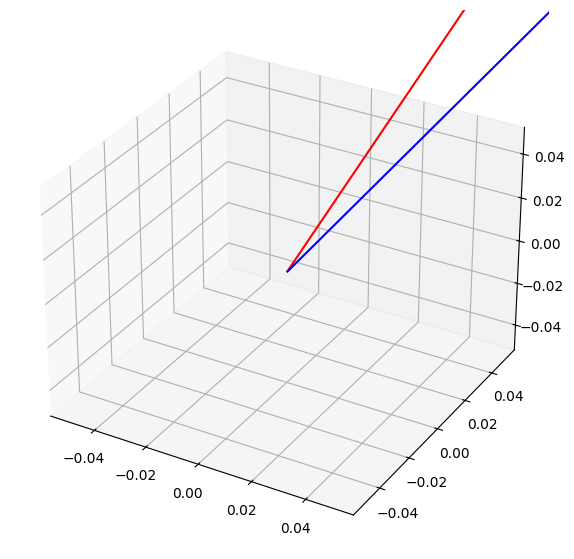

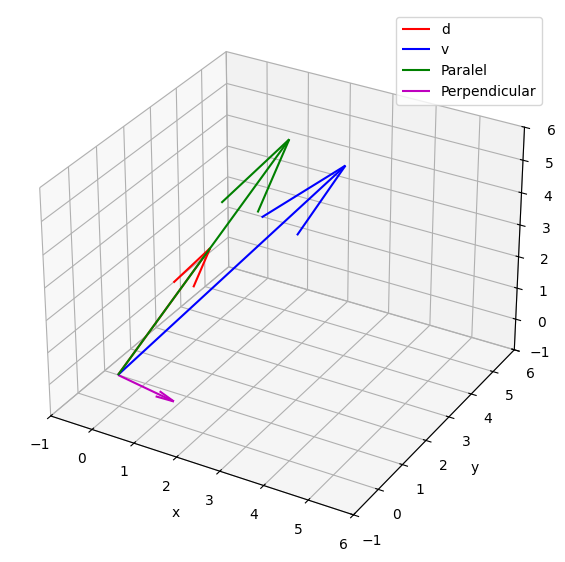

In [182]:
def projection_matrix(a):
    return np.outer(a, a) / np.dot(a, a)


def decomposition(v, d):
    if v.shape != d.shape:
        raise ValueError("Input vectors must have the same shape.")

    P_parallel = projection_matrix(d)
    P_perp = np.eye(len(d)) - P_parallel

    v_parallel = P_parallel @ v
    v_perp = P_perp @ v

    return v_parallel, v_perp, P_parallel, P_perp


# Example in 3D
v = np.array([3, 4, 5], dtype=float)
d = np.array([1, 2, 3], dtype=float)

v_par, v_perp, P_par, P_perp = decomposition(v, d)
print(v)
print(d)
print(v_par)
print(v_perp)
print(P_par)
print(P_perp)

# Optional 3D visualization
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

origin = np.zeros(3)
ax.quiver(*origin, *d, color='r', label='d')
ax.quiver(*origin, *v, color='b', label='v')
ax.quiver(*origin, *v_par, color='g', label='Paralel')
ax.quiver(*origin, *v_perp, color='m', label='Perpendicular')

ax.set_xlim([-1, 6])
ax.set_ylim([-1, 6])
ax.set_zlim([-1, 6])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
plt.show()

### Task 3: Volume of a parallelepiped 

A parallelelepiped can be defined with a $3\times 3$ matrix, where the coloumns of the matrix contains the vectors spanning the parallelepiped. Write a function which gets a $3\times 3$ matrix as input and returns the volume of the parallelepiped spanned by the coloumns of the matrix.

1. Check that the defined object is three dimensional. 
2. Calculate the volume using the formula $V=A\cdot h$, where $A$ is the base area and $h$ is the corresponding height of the parallelepiped. Hint: |Use the cross product to calculate the area of the base.
3. Extend your code to also calculate the total surface are of the parallelepiped.

In [179]:
def volume_and_surface(A):
    A = np.asarray(A, dtype=float)

    if A.shape != (3, 3):
        raise ValueError("Input must be a 3x3 matrix.")

    a, b, c = A[:, 0], A[:, 1], A[:, 2]

    
    volume = abs(np.linalg.det(A))

    face_areas = [
        np.linalg.norm(np.cross(b, c)),
        np.linalg.norm(np.cross(a, c)),
        np.linalg.norm(np.cross(a, b)),
    ]
    total_surface_area = 2 * (np.cross(b, c).size + np.cross(a, c).size + np.cross(a, b).size)

    return volume, total_surface_area

A_test = np.array([
    [1, 2, 3],
    [0, 1, 4],
    [5, 6, 0]
], dtype=float)

V, S = volume_and_surface(A_test)
print("Volume:", V)
print("Total surface area:", S)

Volume: 0.9999999999999964
Total surface area: 18


## Recap on the linear transformations

![](https://miro.medium.com/v2/resize:fit:720/format:webp/0*rAAM3EWn0Q5MRGWp.png)
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*QCGKz_TZPBhYOjTIm55A7w.jpeg)

## Why do we care

We like in physics if we make a translation for instance, then our equations, or at least their message, do not change. Recall special relativity to be invariant under Lorentz transformations, which are affine transformations.

Affine transformations are also heavily used in image manipulation and data augmentation methods. Data augmentation is one of the cornerstones of effectively training some (deep) neural networks and in enhancing the image recognition capabilities of certain AI models. See for more YOLO model, Fast-CNN or General Object Detection algorithms. 



### Task 4: Affine Transformation of an Image

The code below loads an image and provides a `show()` function for comparing the original and transformed images.

Using `scipy.ndimage.affine_transform`, construct an affine transformation that transforms the given image so that it appears **normally oriented, centered, and scaled to fill the image area as much as possible without being cropped**.

Use a combination of:

1. **Translation** 
2. **Scaling** 
3. **Rotation** 

Represent each transformation using a matrix and combine the transformations into a single affine transformation matrix. Use the provided `show()` function to display the original and transformed images side by side.

The image is already approximately centered, so you should choose the rotation angle and scaling factor appropriately to obtain the desired final appearance.

**Hint:** Scaling and rotation are performed around the origin. Since the image coordinates start at the top-left corner, first **translate the image so that its center is at the origin**. Perform the scaling and rotation there, and then translate it back to the image coordinates.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2387975..1.2570193].


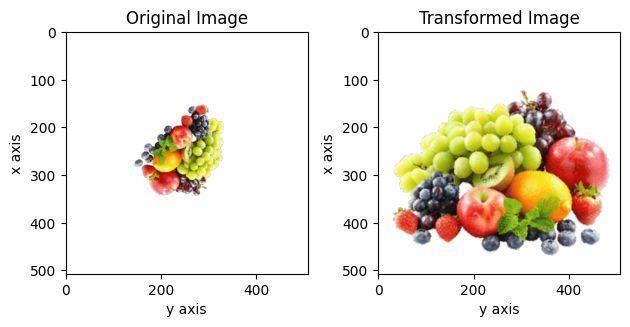

In [173]:
from scipy.ndimage import affine_transform
import matplotlib as mpl
from matplotlib.image import imread
mpl.rcParams.update(mpl.rcParamsDefault)

def show(image, transformedImage):
    
    fig, ax = plt.subplots(nrows=1, ncols=2, dpi=100)
    
    ax[0].set_title('Original Image')
    ax[0].imshow(image, cmap='gray')
    ax[0].set_xlabel('y axis')
    ax[0].set_ylabel('x axis')

    ax[1].set_title('Transformed Image')
    ax[1].imshow(transformedImage, cmap='gray')
    ax[1].set_xlabel('y axis')
    ax[1].set_ylabel('x axis')
    
    fig.tight_layout()
    
    plt.show()
    
def rgbTransform(image, matrix):
    transformed_image = np.empty_like(image)
    for i in range(4):
        transformed_image[..., i] = affine_transform(image[..., i], matrix)
    return transformed_image


image = imread('fruits.png') 

#plt.figure(figsize=(8, 4), dpi = 150)
#plt.imshow(image, cmap='gray')
#plt.xlabel('y axis')
#plt.ylabel('x axis')
#plt.show()

rotate = np.array([[np.cos(np.radians(135)), -np.sin(np.radians(135)), 0],
                   [np.sin(np.radians(135)), np.cos(np.radians(135)), 0],
                   [0, 0, 1]])

transformation = np.array([
    [.45, 0, 270],
    [0, .45, 430],
    [0, 0, 1]
]) @ rotate.T

show(image, rgbTransform(image, transformation))